In [71]:
import pandas as pd
import numpy as np

In [72]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/covid_19_clean_complete.csv")

In [73]:
province_state = df["Province/State"].to_numpy()
print(province_state)

[nan nan nan ... nan nan nan]


In [74]:
Country_Region = df["Country/Region"].to_numpy()
print(province_state)

[nan nan nan ... nan nan nan]


In [75]:
Lat = df["Lat"].to_numpy()
print(Lat)

[ 33.93911  41.1533   28.0339  ... -11.6455   38.861   -29.61   ]


In [76]:
Long = df["Long"].to_numpy()
print(Long)

[67.709953 20.1683    1.6596   ... 43.3333   71.2761   28.2336  ]


In [77]:
Date = df["Date"].to_numpy()
print(Date)

['2020-01-22' '2020-01-22' '2020-01-22' ... '2020-07-27' '2020-07-27'
 '2020-07-27']


In [78]:
Confirmed = df["Confirmed"].to_numpy()
print(Confirmed)

[   0    0    0 ...  354 7235  505]


In [79]:
Deaths = df["Deaths"].to_numpy()
print(Deaths)

[ 0  0  0 ...  7 60 12]


In [80]:
Recovered = df["Recovered"].to_numpy()
print(Recovered)

[   0    0    0 ...  328 6028  128]


In [81]:
Active = df["Active"].to_numpy()
print(Active)

[   0    0    0 ...   19 1147  365]


In [82]:
WHO_Region = df["WHO Region"].to_numpy()
print(WHO_Region)

['Eastern Mediterranean' 'Europe' 'Africa' ... 'Africa' 'Europe' 'Africa']


In [83]:
selected_columns = [
    'Province/State',
    'Country/Region',
    'Lat',
    'Long',
    'Date',
    'Confirmed',
    'Deaths',
    'Recovered',
    'Active',
    'WHO Region'
]

df_selected = df[selected_columns].copy()
display(df_selected.head())

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [84]:
missing_values = df_selected.isnull().sum()
display(missing_values[missing_values > 0])

,0
Province/State,34404


In [85]:
df_selected['Province/State'] = df_selected['Province/State'].fillna('Unknown')
missing_values = df_selected.isnull().sum()
display(missing_values[missing_values > 0])

,0


In [86]:
df_selected['Date'] = pd.to_datetime(df_selected['Date'])
display(df_selected.head())

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,Unknown,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,Unknown,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,Unknown,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,Unknown,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,Unknown,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [87]:
initial_rows = df_selected.shape[0]
df_selected.drop_duplicates(inplace=True)
final_rows = df_selected.shape[0]

print(f"Initial number of rows: {initial_rows}")
print(f"Number of rows after removing duplicates: {final_rows}")
print(f"Number of duplicate rows removed: {initial_rows - final_rows}")

Initial number of rows: 49068
Number of rows after removing duplicates: 49068
Number of duplicate rows removed: 0


In [88]:
df_selected['Active'] = df_selected['Active'].apply(lambda x: max(x, 0))

In [89]:
total_confirmed = df_selected['Confirmed'].sum()
total_deaths = df_selected['Deaths'].sum()
total_recovered = df_selected['Recovered'].sum()

print(f"Total Confirmed Cases: {total_confirmed}")
print(f"Total Deaths: {total_deaths}")
print(f"Total Recovered: {total_recovered}")

Total Confirmed Cases: 828508482
Total Deaths: 43384903
Total Recovered: 388408229


In [90]:
numerical_columns = ['Confirmed', 'Deaths', 'Recovered', 'Active']
display(df_selected[numerical_columns].describe())

,Confirmed,Deaths,Recovered,Active
count,4.906800e+04,49068.000000,4.906800e+04,4.906800e+04
mean,1.688490e+04,884.179160,7.915713e+03,8.085014e+03
std,1.273002e+05,6313.584411,5.480092e+04,7.625890e+04
min,0.000000e+00,0.000000,0.000000e+00,0.000000e+00
25%,4.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,1.680000e+02,2.000000,2.900000e+01,2.600000e+01
75%,1.518250e+03,30.000000,6.660000e+02,6.060000e+02
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06


In [91]:
confirmed_cases_over_time = df_selected.groupby('Date')['Confirmed'].sum().reset_index()
display(confirmed_cases_over_time.head())

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118


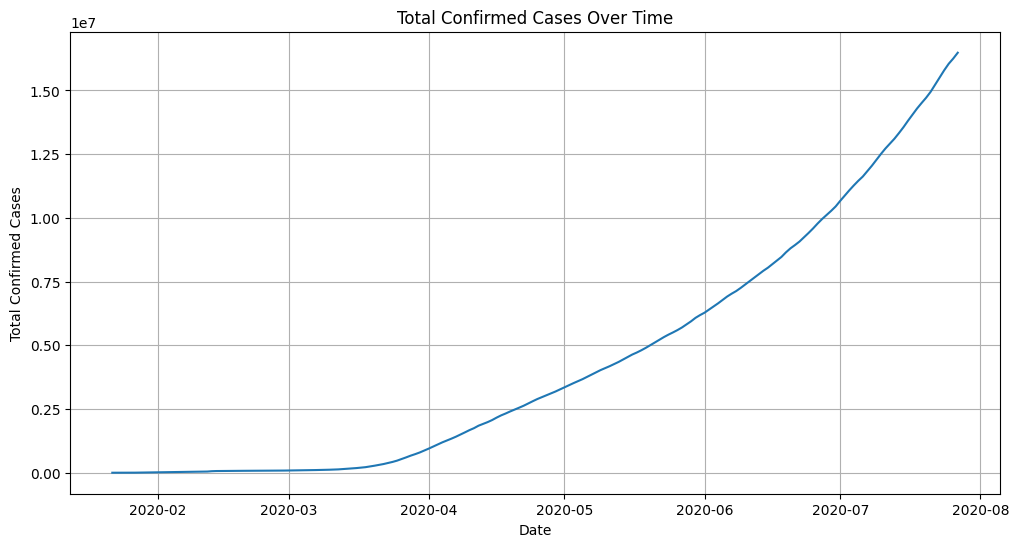

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Confirmed', data=confirmed_cases_over_time)
plt.title('Total Confirmed Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Total Confirmed Cases')
plt.grid(True)
plt.show()

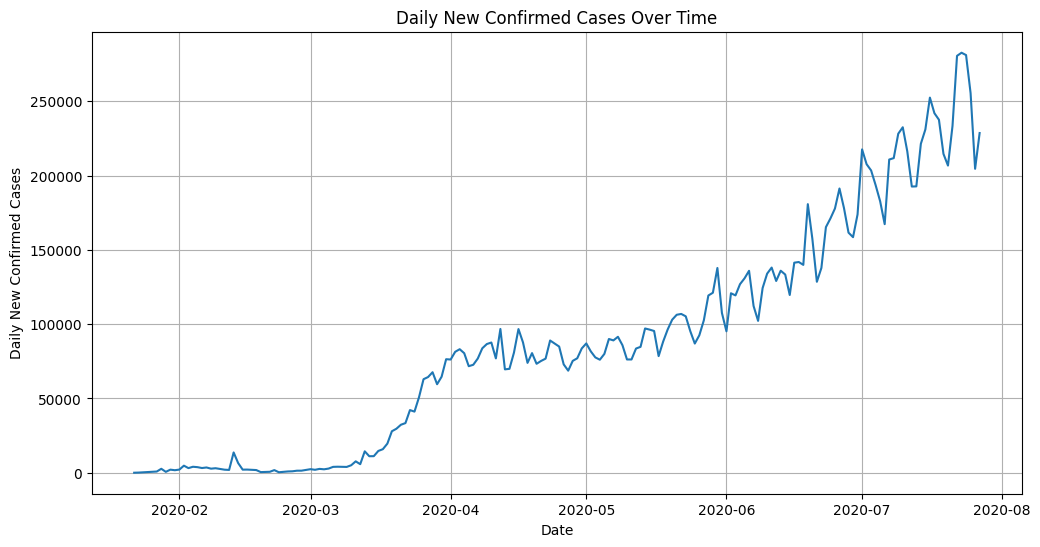

Peak daily new confirmed cases occurred on 2020-07-23 with 282756 cases.


In [93]:
confirmed_cases_over_time['Daily New Confirmed'] = confirmed_cases_over_time['Confirmed'].diff().fillna(0)

plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Daily New Confirmed', data=confirmed_cases_over_time)
plt.title('Daily New Confirmed Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Daily New Confirmed Cases')
plt.grid(True)
plt.show()

peak_date = confirmed_cases_over_time.loc[confirmed_cases_over_time['Daily New Confirmed'].idxmax()]
print(f"Peak daily new confirmed cases occurred on {peak_date['Date'].strftime('%Y-%m-%d')} with {int(peak_date['Daily New Confirmed'])} cases.")

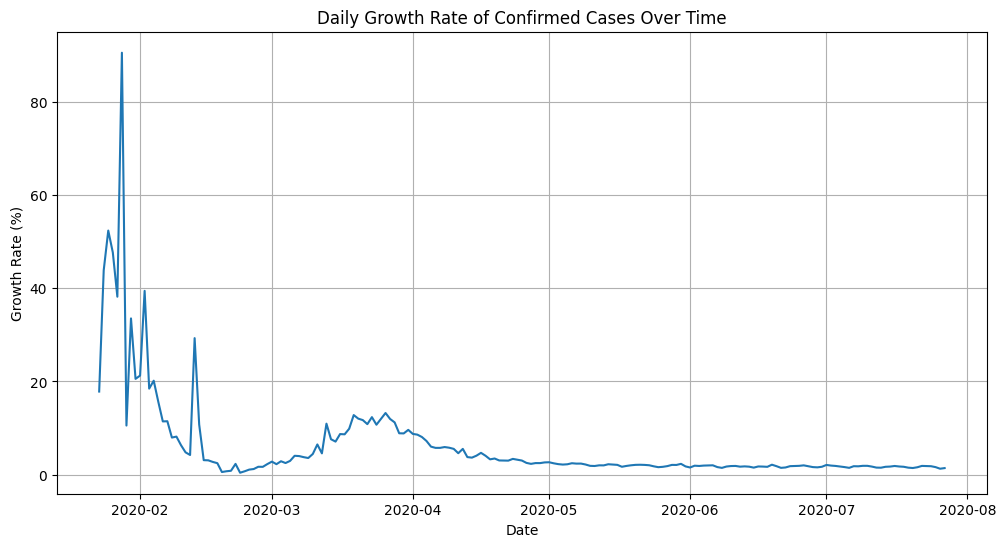

In [94]:
confirmed_cases_over_time['Growth Rate'] = confirmed_cases_over_time['Confirmed'].pct_change() * 100

plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Growth Rate', data=confirmed_cases_over_time)
plt.title('Daily Growth Rate of Confirmed Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Growth Rate (%)')
plt.grid(True)
plt.show()

In [95]:
country_cases = df_selected.groupby('Country/Region')[['Confirmed', 'Deaths', 'Recovered']].sum().reset_index()


top_confirmed_countries = country_cases.sort_values(by='Confirmed', ascending=False).head(10)
print('Top 10 Countries by Confirmed Cases:')
display(top_confirmed_countries)


top_deaths_countries = country_cases.sort_values(by='Deaths', ascending=False).head(10)
print('\nTop 10 Countries by Deaths:')
display(top_deaths_countries)


top_recovered_countries = country_cases.sort_values(by='Recovered', ascending=False).head(10)
print('\nTop 10 Countries by Recovered Cases:')
display(top_recovered_countries)

Top 10 Countries by Confirmed Cases:


,Country/Region,Confirmed,Deaths,Recovered
173,US,224345948,11011411,56353416
23,Brazil,89524967,3938034,54492873
138,Russia,45408411,619385,25120448
79,India,40883464,1111831,23783720
157,Spain,27404045,3033030,15093583
177,United Kingdom,26748587,3997775,126217
85,Italy,26745145,3707717,15673910
61,France,21210926,3048524,7182115
65,Germany,21059152,871322,17107839
81,Iran,19339267,1024136,15200895



Top 10 Countries by Deaths:


,Country/Region,Confirmed,Deaths,Recovered
173,US,224345948,11011411,56353416
177,United Kingdom,26748587,3997775,126217
23,Brazil,89524967,3938034,54492873
85,Italy,26745145,3707717,15673910
61,France,21210926,3048524,7182115
157,Spain,27404045,3033030,15093583
111,Mexico,14946202,1728277,11141225
79,India,40883464,1111831,23783720
81,Iran,19339267,1024136,15200895
16,Belgium,6281116,963679,1627492



Top 10 Countries by Recovered Cases:


,Country/Region,Confirmed,Deaths,Recovered
173,US,224345948,11011411,56353416
23,Brazil,89524967,3938034,54492873
138,Russia,45408411,619385,25120448
79,India,40883464,1111831,23783720
65,Germany,21059152,871322,17107839
85,Italy,26745145,3707717,15673910
81,Iran,19339267,1024136,15200895
157,Spain,27404045,3033030,15093583
172,Turkey,17903345,466056,13345389
35,Chile,16935654,322480,13292593


/tmp/ipykernel_16688/718185953.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Confirmed', y='Country/Region', data=top_confirmed_countries, palette='viridis')


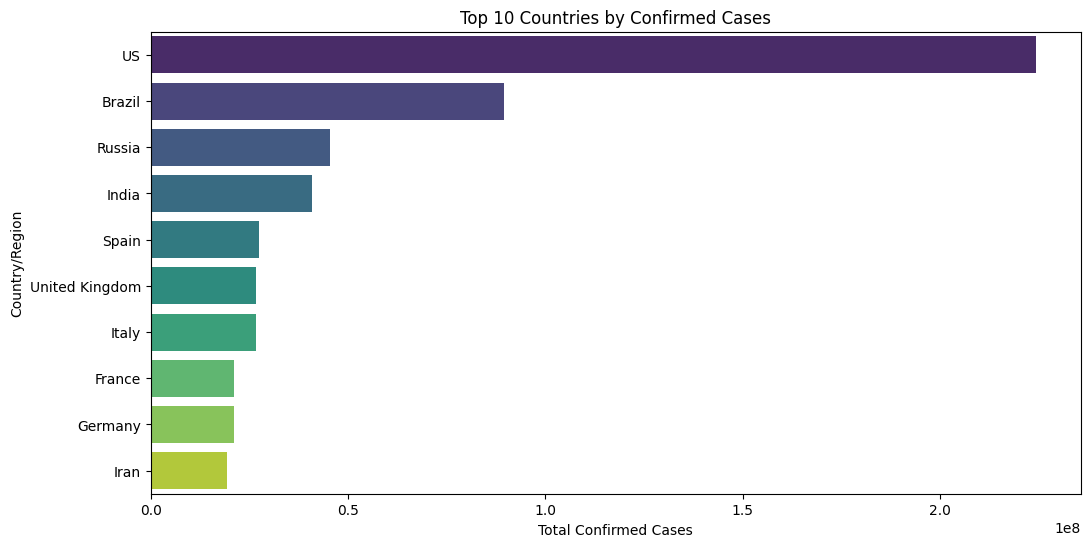

/tmp/ipykernel_16688/718185953.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Deaths', y='Country/Region', data=top_deaths_countries, palette='plasma')


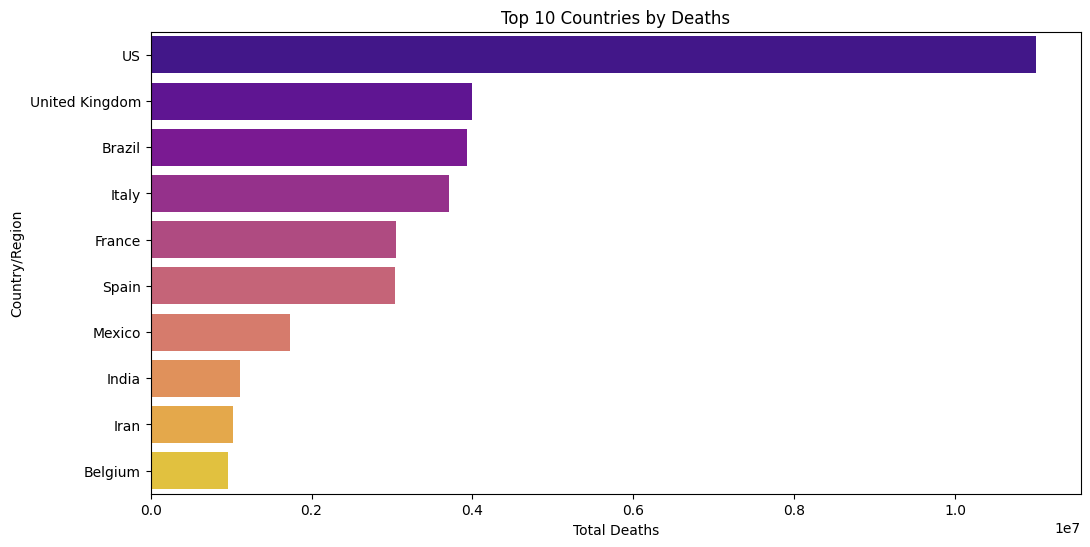

/tmp/ipykernel_16688/718185953.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Recovered', y='Country/Region', data=top_recovered_countries, palette='Greens')


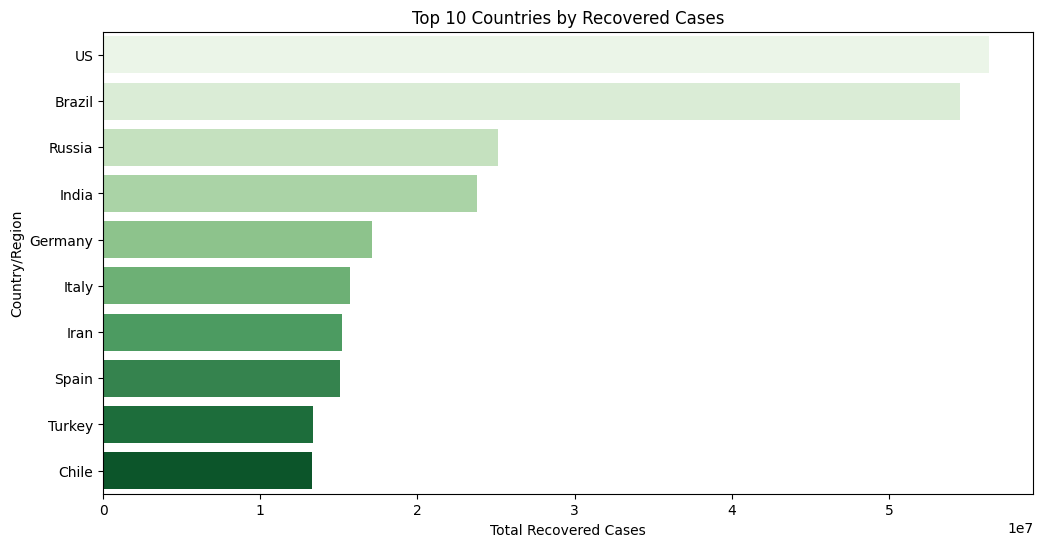

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='Confirmed', y='Country/Region', data=top_confirmed_countries, palette='viridis')
plt.title('Top 10 Countries by Confirmed Cases')
plt.xlabel('Total Confirmed Cases')
plt.ylabel('Country/Region')
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='Deaths', y='Country/Region', data=top_deaths_countries, palette='plasma')
plt.title('Top 10 Countries by Deaths')
plt.xlabel('Total Deaths')
plt.ylabel('Country/Region')
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='Recovered', y='Country/Region', data=top_recovered_countries, palette='Greens')
plt.title('Top 10 Countries by Recovered Cases')
plt.xlabel('Total Recovered Cases')
plt.ylabel('Country/Region')
plt.show()

Correlation between Confirmed and Deaths: 0.91


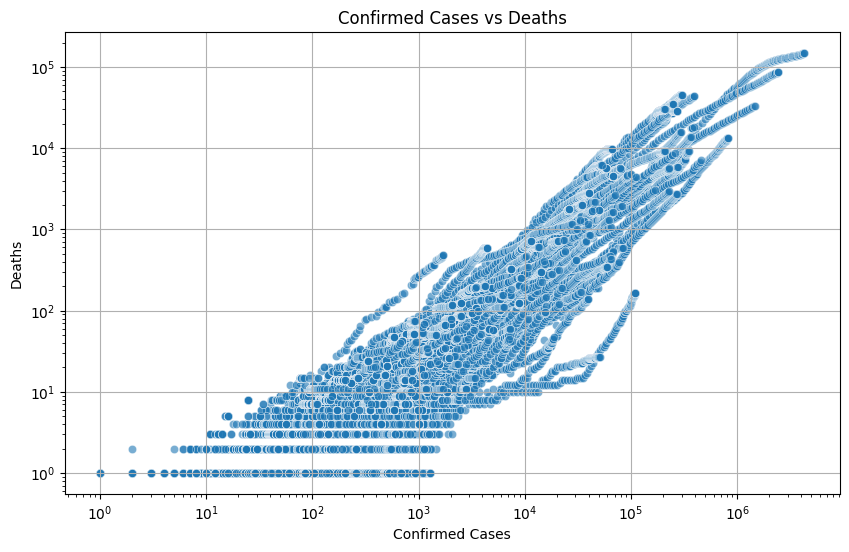

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns


correlation_confirmed_deaths = df_selected['Confirmed'].corr(df_selected['Deaths'])
print(f"Correlation between Confirmed and Deaths: {correlation_confirmed_deaths:.2f}")


plt.figure(figsize=(10, 6))
sns.scatterplot(x='Confirmed', y='Deaths', data=df_selected, alpha=0.6)
plt.title('Confirmed Cases vs Deaths')
plt.xlabel('Confirmed Cases')
plt.ylabel('Deaths')
plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.show()

Correlation between Confirmed and Recovered: 0.90


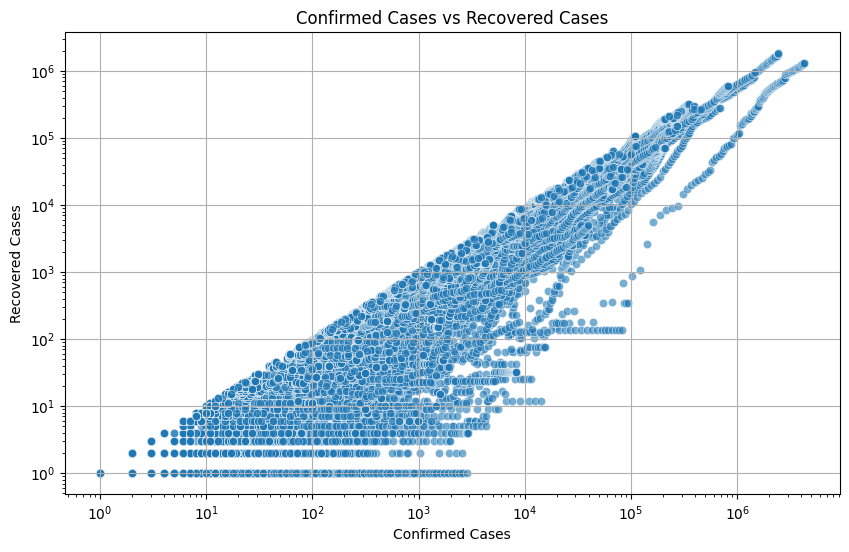

In [98]:

correlation_confirmed_recovered = df_selected['Confirmed'].corr(df_selected['Recovered'])
print(f"Correlation between Confirmed and Recovered: {correlation_confirmed_recovered:.2f}")


plt.figure(figsize=(10, 6))
sns.scatterplot(x='Confirmed', y='Recovered', data=df_selected, alpha=0.6)
plt.title('Confirmed Cases vs Recovered Cases')
plt.xlabel('Confirmed Cases')
plt.ylabel('Recovered Cases')
plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.show()

Correlation between Active and Confirmed: 0.95


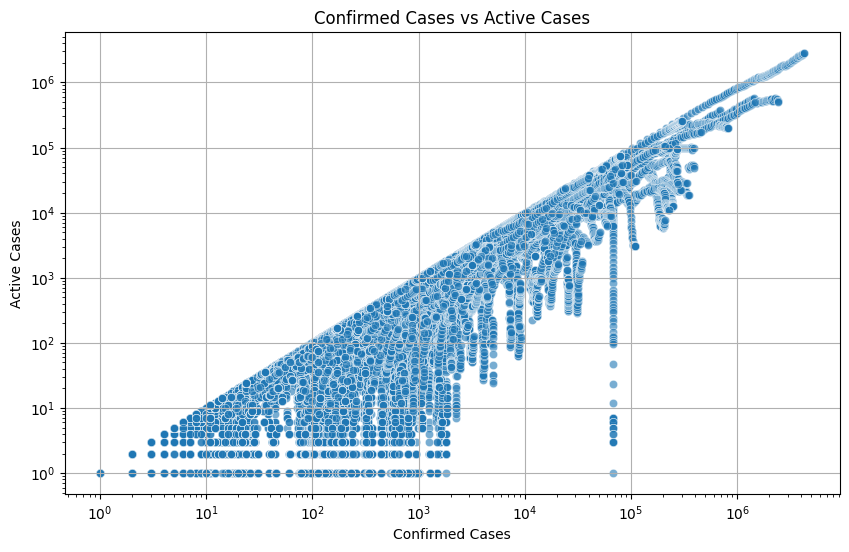

In [99]:

correlation_active_confirmed = df_selected['Active'].corr(df_selected['Confirmed'])
print(f"Correlation between Active and Confirmed: {correlation_active_confirmed:.2f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Confirmed', y='Active', data=df_selected, alpha=0.6)
plt.title('Confirmed Cases vs Active Cases')
plt.xlabel('Confirmed Cases')
plt.ylabel('Active Cases')
plt.xscale('log')
plt.yscale('log')
plt.grid(True)
plt.show()